## **Phase 3 วิเคราะห์และจำแนกพฤติกรรมไฟ**

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from shapely.geometry import MultiPoint, Point, box
from shapely.ops import unary_union
import os
import warnings
warnings.filterwarnings('ignore')

In [2]:
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'TH Sarabun New'
plt.rcParams['axes.unicode_minus'] = False

In [3]:
# ══════════════════════════════════════════════════════════════════
#  กำหนด Path และ Constants ทั้งหมดในเซลล์นี้ที่เดียว
# ══════════════════════════════════════════════════════════════════

BASE_PATH = r"D:\gistnu\ST-DBSCAN\file_final\Phase 3 Final"

# ── Input / Output ────────────────────────────────────────────────
PATH_INPUT  = r"D:\gistnu\ST-DBSCAN\file_final\Phase 3 Final\phase 2\hotspot_clustered_final.gpkg"
PATH_OUTPUT = os.path.join(BASE_PATH, "hotspot_classified_final.gpkg")
PATH_POLY   = os.path.join(BASE_PATH, "cluster_polygons_final.gpkg")
PATH_RECUR  = os.path.join(BASE_PATH, "repeat_burn_grid_final.gpkg")
PATH_CSV    = os.path.join(BASE_PATH, "cluster_summary_final.csv")

# ── Boundary (สำหรับ clip polygon) ───────────────────────────────
PATH_BOUNDARY = r"D:\gistnu\tha_admin_boundaries.shp\tha_admin2.shp"

# ── Repeat-burn: ใช้เฉพาะปีที่เก็บข้อมูลครบ ──────────────────────
# 2026 มีเพียง ม.ค.–เม.ย. → ตัดออกเพื่อให้นับปีเผาซ้ำได้ยุติธรรม
FULL_YEARS = list(range(2020, 2026))   # 2020–2025 = 6 ปีเต็ม

# ── Plot output ───────────────────────────────────────────────────
PLOT_DIR = os.path.join(BASE_PATH, "plots")
os.makedirs(PLOT_DIR, exist_ok=True)

assert os.path.exists(PATH_INPUT),    f"✗ ไม่พบไฟล์: {PATH_INPUT}"
assert os.path.exists(PATH_BOUNDARY), f"✗ ไม่พบ boundary: {PATH_BOUNDARY}"
print(f"✓ PATH_INPUT   : {PATH_INPUT}")
print(f"✓ PATH_OUTPUT  : {PATH_OUTPUT}")
print(f"✓ FULL_YEARS   : {FULL_YEARS[0]}–{FULL_YEARS[-1]}")


✓ PATH_INPUT   : D:\gistnu\ST-DBSCAN\file_final\Phase 3 Final\phase 2\hotspot_clustered_final.gpkg
✓ PATH_OUTPUT  : D:\gistnu\ST-DBSCAN\file_final\Phase 3 Final\hotspot_classified_final.gpkg
✓ FULL_YEARS   : 2020–2025


In [4]:
# CELL 2 — โหลดข้อมูลจาก Phase 2
gdf = gpd.read_file(PATH_INPUT)
print(f"โหลดสำเร็จ: {len(gdf):,} แถว | {len(gdf.columns)} columns")
print(f"CRS: {gdf.crs}")

โหลดสำเร็จ: 2,458 แถว | 29 columns
CRS: EPSG:32647


In [5]:
# แยก cluster และ noise
gdf_cluster = gdf[gdf['cluster_id'] != -1].copy()
gdf_noise   = gdf[gdf['cluster_id'] == -1].copy()
n_clusters  = gdf_cluster['cluster_id'].nunique()
 
print(f"จุดใน cluster: {len(gdf_cluster):,} | noise: {len(gdf_noise):,}")
print(f"จำนวน cluster: {n_clusters:,}")

จุดใน cluster: 316 | noise: 2,142
จำนวน cluster: 33


In [6]:
# --- CHECKPOINT 2 ---
assert len(gdf) > 0,                        "✗ ไม่มีข้อมูล"
assert 'cluster_id'       in gdf.columns,   "✗ ไม่มี cluster_id"
assert 'burn_season'      in gdf.columns,   "✗ ไม่มี burn_season"
assert 'fire_type'        in gdf.columns,   "✗ ไม่มี fire_type"
assert 'fire_type_detail' in gdf.columns,   "✗ ไม่มี fire_type_detail"
assert 'is_agri'          in gdf.columns,   "✗ ไม่มี is_agri"
assert 'is_forest'        in gdf.columns,   "✗ ไม่มี is_forest"
assert 'dist_agri_m'      in gdf.columns,   "✗ ไม่มี dist_agri_m"
assert 'dist_forest_m'    in gdf.columns,   "✗ ไม่มี dist_forest_m"
assert 'land_use_type'    in gdf.columns,   "✗ ไม่มี land_use_type"
assert 'amphoe'           in gdf.columns,   "✗ ไม่มี amphoe"
assert gdf['cluster_id'].notna().all(),     "✗ cluster_id มี null"
print("✓ ตรวจสอบ input ผ่านทุกรายการ")
print(f"✓ fire_type: {gdf['fire_type'].value_counts().to_dict()}")
print(f"✓ columns: {len(gdf.columns)} columns")


✓ ตรวจสอบ input ผ่านทุกรายการ
✓ fire_type: {'agricultural': 2108, 'other': 221, 'forest': 129}
✓ columns: 29 columns


In [7]:
cluster_stats = []

for cid, group in gdf_cluster.groupby('cluster_id'):
    coords = list(zip(group['x_utm'], group['y_utm']))

    # 3.1 พื้นที่ cluster
    points_geom = [Point(x, y).buffer(187.5) for x, y in coords]
    union_geom  = unary_union(points_geom)
    area_m2     = union_geom.area
    area_rai    = area_m2 / 1600

    # 3.2 ระยะเวลาการเผา (ใช้ t_days แทน)
    doy_range = int(group['t_days'].max() - group['t_days'].min())

    # 3.3 จำนวนจุด
    n_points = len(group)

    # 3.4 FRP
    frp_mean = group['frp'].mean()
    frp_max  = group['frp'].max()

    # 3.5 burn_season ที่พบบ่อยสุด
    burn_season = group['burn_season'].mode()[0]

    # 3.6 อำเภอที่พบบ่อยสุด
    amphoe = group['amphoe'].mode()[0] if group['amphoe'].notna().any() else 'ไม่ทราบ'

    # 3.7 สัดส่วนพื้นที่เกษตรและป่า
    agri_ratio   = group['is_agri'].mean()
    forest_ratio = group['is_forest'].mean()

    # 3.8 fire_type และ fire_type_detail ที่พบบ่อยสุด
    fire_type        = group['fire_type'].mode()[0]
    fire_type_detail = group['fire_type_detail'].mode()[0]

    # 3.9 ประเภทที่ดินที่พบบ่อยสุด
    land_use = group['land_use_type'].mode()[0]

    # 3.10 ระยะห่างเฉลี่ยจากเกษตรและป่า
    dist_agri_mean   = group['dist_agri_m'].mean()
    dist_forest_mean = group['dist_forest_m'].mean()

    # 3.11 ปีที่เกิดไฟบ่อยสุด และปีที่ active ทั้งหมด
    year           = pd.to_datetime(group['acq_date']).dt.year.mode()[0]
    years_active   = sorted(pd.to_datetime(group['acq_date']).dt.year.unique().tolist())
    n_years_active = len(years_active)

    # 3.12 centroid
    cx = group['x_utm'].mean()
    cy = group['y_utm'].mean()

    # 3.13 ช่วงวันในปฏิทิน (คำนวณจาก acq_date — ใช้ทำปฏิทินไฟใน Phase 4)
    _doy      = pd.to_datetime(group['acq_date']).dt.dayofyear
    doy_start = int(_doy.min())
    doy_end   = int(_doy.max())

    # 3.14 สัดส่วนกลางวันต่อ cluster (คำนวณจาก is_day รายจุด)
    day_pct = round(group['is_day'].mean() * 100, 1)   # % ของจุดที่เป็นกลางวัน

    # threshold: active >= 2 ปี = repeat burn
    repeat_burn = int(group['acq_date'].apply(lambda x: pd.to_datetime(x).year).nunique()) >= 2

    doy_min = doy_start   # alias (ใช้ใน polygon/export)
    doy_max = doy_end     # alias

    cluster_stats.append({
        'cluster_id'      : cid,
        'n_points'        : n_points,
        'area_rai'        : round(area_rai, 2),
        'duration_days'   : doy_range,
        'frp_mean'        : round(frp_mean, 2),
        'frp_max'         : round(frp_max, 2),
        'burn_season'     : burn_season,
        'amphoe'          : amphoe,
        'agri_ratio'      : round(agri_ratio, 3),
        'forest_ratio'    : round(forest_ratio, 3),
        'fire_type'       : fire_type,
        'fire_type_detail': fire_type_detail,
        'land_use_type'   : land_use,
        'dist_agri_m'     : round(dist_agri_mean, 1),
        'dist_forest_m'   : round(dist_forest_mean, 1),
        'year'            : year,
        'years_active'    : str(years_active),
        'n_years_active'  : n_years_active,
        'centroid_x'      : round(cx, 2),
        'centroid_y'      : round(cy, 2),
        'doy_start'       : doy_start,
        'doy_end'         : doy_end,
        'repeat_burn'     : repeat_burn,
        'doy_min'         : doy_min,
        'doy_max'         : doy_max,
        'day_pct'         : day_pct,
    })

df_cluster = pd.DataFrame(cluster_stats)
print(f"คำนวณ derived features สำเร็จ: {len(df_cluster):,} clusters")
print(df_cluster[['n_points','area_rai','duration_days','frp_mean','agri_ratio','forest_ratio','n_years_active']].describe().round(2).to_string())

คำนวณ derived features สำเร็จ: 33 clusters
       n_points  area_rai  duration_days  frp_mean  agri_ratio  forest_ratio  n_years_active
count     33.00     33.00          33.00     33.00       33.00         33.00           33.00
mean       9.58    272.62          31.91      1.94        0.70          0.30            1.12
std       11.69    194.65          43.55      1.52        0.47          0.47            0.33
min        3.00    127.51           0.00      0.34        0.00          0.00            1.00
25%        4.00    189.98           1.00      0.78        0.00          0.00            1.00
50%        5.00    222.54          14.00      1.41        1.00          0.00            1.00
75%        7.00    282.34          45.00      2.74        1.00          1.00            1.00
max       54.00   1235.83         183.00      7.11        1.00          1.00            2.00


In [8]:
# ── เช็ก cluster ที่ต้องระวังตอนแปลผล (ไม่ลบทิ้ง แค่ทำ flag) ──
df_cs = pd.DataFrame(cluster_stats)

tiny  = df_cs[df_cs['n_points'] <= 4]
longd = df_cs[df_cs['duration_days'] > 90]
multi = df_cs[df_cs['n_years_active'] >= 2]

print(f"cluster ทั้งหมด: {len(df_cs)}")
print(f"  • ขนาดเล็ก (≤4 จุด)        : {len(tiny)} cluster "
      f"({len(tiny)/len(df_cs)*100:.0f}%) — สรุปพฤติกรรมเชิงสถิติได้จำกัด")
print(f"  • ระยะเวลายาวผิดปกติ (>90 วัน): {len(longd)} cluster "
      f"— อาจเป็นการลากต่อข้ามเหตุการณ์ ควรดูประกอบ")
print(f"  • คาบเกี่ยว 2 ปี (n_years≥2)  : {len(multi)} cluster "
      f"— ไม่ใช่เผาซ้ำ (ใช้ grid แยกต่างหาก)")

if len(longd) > 0:
    print("\nรายละเอียด cluster ระยะเวลายาว (>90 วัน):")
    print(longd[['cluster_id', 'fire_type', 'n_points',
                 'duration_days', 'n_years_active']].to_string(index=False))
# ── การกระจาย n_years_active (ยืนยันว่า t_days clustering ถูกต้อง) ──────────
# ≈88% ควรเป็น 1 ปี — พิสูจน์ว่า cluster จับเหตุการณ์ไฟในปีเดียว
nmax_y = int(df_cluster["n_years_active"].max())
for y in range(1, nmax_y + 1):
    cnt = (df_cluster["n_years_active"] == y).sum()
    if cnt > 0:
        print(f"  active {y} ปี : {cnt} cluster")


cluster ทั้งหมด: 33
  • ขนาดเล็ก (≤4 จุด)        : 16 cluster (48%) — สรุปพฤติกรรมเชิงสถิติได้จำกัด
  • ระยะเวลายาวผิดปกติ (>90 วัน): 5 cluster — อาจเป็นการลากต่อข้ามเหตุการณ์ ควรดูประกอบ
  • คาบเกี่ยว 2 ปี (n_years≥2)  : 4 cluster — ไม่ใช่เผาซ้ำ (ใช้ grid แยกต่างหาก)

รายละเอียด cluster ระยะเวลายาว (>90 วัน):
 cluster_id    fire_type  n_points  duration_days  n_years_active
          0 agricultural        54            102               1
          1 agricultural        17            108               1
          9 agricultural        14             91               1
         13 agricultural        38            183               2
         17 agricultural        35            123               1
  active 1 ปี : 29 cluster
  active 2 ปี : 4 cluster


In [9]:
# --- CHECKPOINT 3 ---
print("\n[CHECKPOINT 3] ตรวจสอบ Derived Features")

# ตรวจ missing
missing = df_cluster.isnull().sum()
print(f"Missing values:\n{missing[missing > 0] if missing.sum() > 0 else 'ไม่พบ'}")

# ตรวจค่าผิดปกติ
assert len(df_cluster) == n_clusters,           "✗ จำนวน cluster ไม่ตรง"
assert df_cluster['n_points'].min() > 0,        "✗ มี cluster ที่ไม่มีจุด"
assert df_cluster['duration_days'].min() >= 0,  "✗ duration ติดลบ"
assert df_cluster['agri_ratio'].between(0,1).all(), "✗ agri_ratio นอกช่วง"
assert df_cluster['frp_mean'].min() > 0,        "✗ frp_mean <= 0"
assert df_cluster['area_rai'].min() > 0,        "✗ area_rai <= 0"

# ตรวจ burn_season
print(f"\nburn_season:\n{df_cluster['burn_season'].value_counts().to_string()}")

# ตรวจ amphoe ครบ 9 อำเภอไหม
print(f"\namphoe ({df_cluster['amphoe'].nunique()} อำเภอ):\n{df_cluster['amphoe'].value_counts().to_string()}")

# ตรวจ year
print(f"\nyear:\n{df_cluster['year'].value_counts().sort_index().to_string()}")

# ตรวจ duration outlier
long_fire = (df_cluster['duration_days'] > 30).sum()
print(f"\ncluster เผานานกว่า 30 วัน: {long_fire} cluster")

# ตรวจ frp outlier
high_frp = (df_cluster['frp_mean'] > 20).sum()
print(f"cluster FRP เฉลี่ย > 20 MW: {high_frp} cluster")

print("\n✓ ตรวจสอบ derived features ผ่านทุกรายการ")


[CHECKPOINT 3] ตรวจสอบ Derived Features
Missing values:
ไม่พบ

burn_season:
burn_season
peak_burn          19
early_late_burn     6
pre_season          6
off_season          2

amphoe (2 อำเภอ):
amphoe
Bang Rakam            19
Mueang Phitsanulok    14

year:
year
2020    13
2021     5
2022     5
2023     6
2024     3
2025     1

cluster เผานานกว่า 30 วัน: 11 cluster
cluster FRP เฉลี่ย > 20 MW: 0 cluster

✓ ตรวจสอบ derived features ผ่านทุกรายการ


In [10]:
print("Cluster เผานานกว่า 30 วัน:")
print(df_cluster[df_cluster['duration_days'] > 30][
    ['cluster_id','duration_days','n_points','area_rai','amphoe','burn_season']
].to_string())

print("\nCluster FRP > 20 MW:")
print(df_cluster[df_cluster['frp_mean'] > 20][
    ['cluster_id','frp_mean','frp_max','n_points','amphoe','land_use_type']
].to_string())

Cluster เผานานกว่า 30 วัน:
    cluster_id  duration_days  n_points  area_rai              amphoe      burn_season
0            0            102        54    362.63          Bang Rakam        peak_burn
1            1            108        17    362.35          Bang Rakam        peak_burn
2            2             45         5    161.32          Bang Rakam        peak_burn
6            6             46         6    215.18          Bang Rakam       off_season
8            8             57         4    144.52          Bang Rakam       pre_season
9            9             91        14    396.09          Bang Rakam        peak_burn
10          10             39         7    133.50          Bang Rakam        peak_burn
11          11             35         4    154.06          Bang Rakam  early_late_burn
13          13            183        38    562.07          Bang Rakam        peak_burn
17          17            123        35    304.94          Bang Rakam        peak_burn
25          25  

In [11]:
# ══════════════════════════════════════════════════════════════════════════════
#  จำแนกพฤติกรรมไฟ (Fire Behavior Classification)
#
#  โครงสร้าง: fire_type + fire_type_detail + burn_season → fire_behavior
#    fire_type        (Phase 1) : 'agricultural' | 'forest' | 'other'
#    fire_type_detail (Phase 1) : รหัสชนิดพืช/ป่า เช่น agri_paddy, forest_deciduous
#    burn_season      (Phase 1) : 'pre_season' | 'peak_burn' | 'early_late_burn' | 'off_season'
#
#  หมายเหตุ: 'other' ไม่มีใน df_cluster เพราะ Phase 2 ตัดออกเป็น noise ทั้งหมด
#
#  ──────────────────────────────────────────────────────────────────────────
#  ▶ วิธีปรับให้เข้ากับข้อมูลของตัวเอง:
#
#  [กรณี 1] มีชนิดพืชต่างจากงานวิจัยนี้ (เช่น มีข้าวฟ่าง ทุเรียน ปาล์ม)
#    → แก้ AGRI_BEHAVIOR ด้านล่าง: เพิ่ม key-value ใหม่
#      เช่น  'agri_durian' : 'ไฟทุเรียน'
#    ⚠ ต้องย้อนไปแก้ Phase 1 ด้วย:
#      เพิ่มชื่อใน DETAIL_MAP และ list ของชนิดพืชที่ map ไป key นั้น
#    → Phase 2 ไม่ต้องแก้ (ใช้ fire_type เดิม เพิ่งเพิ่ม detail)
#
#  [กรณี 2] อยากจำแนกโดยไม่ใช้ fire_type_detail (ข้อมูลไม่มีชั้น detail)
#    → แก้ classify_fire_behavior() ให้ return ตาม ft แทน ftd
#      if ft == 'agricultural': return 'ไฟเกษตร'
#      if ft == 'forest':       return 'ไฟป่า'
#    → ไม่ต้องแก้ Phase 1/2
#    → ผลจะหยาบกว่า (ไม่แยกชนิดพืช) แต่รันได้ทันที
#
#  [กรณี 3] เพิ่ม fire_type ใหม่ทั้งหมด (เช่น 'grassland', 'wetland')
#    ต้องย้อนแก้ทุก Phase:
#      Phase 1 : เพิ่ม branch ใน classify_fire_type() + DETAIL_MAP
#      Phase 2 : เพิ่ม entry ใน params และ grid dict
#      Phase 3 : เพิ่ม branch ใน classify_fire_behavior() ที่นี่
#    → รัน Phase 1→2→3 ใหม่ทั้งหมด (sigma เปลี่ยนเมื่อเพิ่ม fire_type)
#
#  [กรณี 4] เปลี่ยนเงื่อนไขพิเศษ (เช่น ไม่ต้องการแยก 'ไฟเตรียมแปลง')
#    → แก้ใน classify_fire_behavior() โดยตรง ไม่ต้องแก้ Phase อื่น
#      ลบ: if ftd == 'agri_paddy' and row['burn_season'] == 'pre_season': ...
#
#  [กรณี 5] ข้อมูล land use ต่างชั้นข้อมูล (ไม่ใช่ LDD ของไทย)
#    → Phase 1 ต้องปรับ DETAIL_MAP ให้ map จาก field ที่มีอยู่จริง
#      Phase 3 ใช้ AGRI_BEHAVIOR ที่ตรงกับ key ใหม่ใน DETAIL_MAP
#    → valid_behaviors (CHECKPOINT 4) ต้องอัปเดตตาม behavior ใหม่ด้วย
#
#  ────────────────────────────────────────────────────────────────────────────
#  สรุป dependency ตามกรณี:
#    เพิ่ม/ลบชนิดพืช   → Phase 1 (DETAIL_MAP) + Phase 3 (AGRI_BEHAVIOR)
#    เพิ่ม fire_type   → Phase 1 + Phase 2 (params/grid) + Phase 3
#    แก้เงื่อนไขพิเศษ → Phase 3 เท่านั้น
#    ข้อมูลต่าง dataset → Phase 1 + Phase 3 (ปรับ mapping ใหม่)
# ══════════════════════════════════════════════════════════════════════════════

AGRI_BEHAVIOR = {
    'agri_paddy'    : 'ไฟนาข้าว',          # + ไฟเตรียมแปลง ถ้า pre_season
    'agri_sugarcane': 'ไฟอ้อย',
    'agri_corn'     : 'ไฟข้าวโพด',
    'agri_cassava'  : 'ไฟมันสำปะหลัง',
    'agri_perennial': 'ไฟไม้ยืนต้น',       # สัก/ยูคาลิปตัส/ยางพารา
    'agri_orchard'  : 'ไฟไม้ผล',
    'agri_mixed'    : 'ไฟเกษตรผสมผสาน',
    'agri_abandoned': 'ไฟพื้นที่เกษตรร้าง',
    'agri_other'    : 'ไฟพื้นที่เกษตรอื่น',  # โรงเรือน/บ่อเพาะเลี้ยง
}

def classify_fire_behavior(row):
    ft  = row['fire_type']
    ftd = row['fire_type_detail']

    # ไฟป่า
    if ft == 'forest' or ftd == 'forest_deciduous':
        return 'ไฟป่าผลัดใบ'

    # ไฟเกษตร — แยกตามชนิดพืช
    if ft == 'agricultural':
        if ftd == 'agri_paddy' and row['burn_season'] == 'pre_season':
            return 'ไฟเตรียมแปลง'
        return AGRI_BEHAVIOR.get(ftd, 'ไฟเกษตรไม่ระบุชนิด')

    return 'ไฟเกษตรไม่ระบุชนิด' 

df_cluster['fire_behavior'] = df_cluster.apply(classify_fire_behavior, axis=1)

# burn_season label (map เดียว — เกษตร/ป่าใช้เหมือนกัน)
SEASON_LABEL = {
    'pre_season'     : 'ช่วงก่อนฤดูเผา',
    'peak_burn'      : 'ช่วงเผาสูงสุด',
    'early_late_burn': 'ช่วงต้นและปลายฤดูเผา',
    'off_season'     : 'ช่วงนอกฤดูเผา',
}
df_cluster['burn_season_label'] = df_cluster['burn_season'].map(
    lambda s: SEASON_LABEL.get(s, s))

# แยก key เฉพาะ pre_season ของป่า (เผื่อใช้ทำสี/กราฟแยกใน Phase 4)
df_cluster['burn_season_display'] = df_cluster.apply(
    lambda r: 'pre_season_forest'
    if (r['fire_type'] == 'forest' and r['burn_season'] == 'pre_season')
    else r['burn_season'], axis=1)

# ── ทาง C: flag cluster ที่ต้องแยกวิเคราะห์ (chaining / คาบเกี่ยวหลายปี) ──
df_cluster['is_long_duration'] = df_cluster['duration_days'] > 90
df_cluster['is_multi_year']    = df_cluster['n_years_active'] >= 2
df_cluster['is_reliable']      = (
    (~df_cluster['is_long_duration']) &
    (~df_cluster['is_multi_year']) &
    (df_cluster['n_points'] >= 5)            # ตัด cluster จิ๋วออกจากกลุ่มที่เชื่อถือได้
)

print("การกระจายของ fire_behavior:")
for fb, cnt in df_cluster['fire_behavior'].value_counts().items():
    print(f"  {fb}: {cnt:,} cluster ({cnt/len(df_cluster)*100:.1f}%)")

print(f"\ncluster เชื่อถือได้ (เหตุการณ์เดี่ยว ≥5 จุด): "
      f"{df_cluster['is_reliable'].sum()} / {len(df_cluster)}")
print(f"  • chaining ยาว >90 วัน : {df_cluster['is_long_duration'].sum()}")
print(f"  • คาบเกี่ยว ≥2 ปี      : {df_cluster['is_multi_year'].sum()}")
print(f"  • ขนาดเล็ก <5 จุด      : {(df_cluster['n_points'] < 5).sum()}")

การกระจายของ fire_behavior:
  ไฟนาข้าว: 15 cluster (45.5%)
  ไฟป่าผลัดใบ: 10 cluster (30.3%)
  ไฟไม้ผล: 5 cluster (15.2%)
  ไฟเตรียมแปลง: 3 cluster (9.1%)

cluster เชื่อถือได้ (เหตุการณ์เดี่ยว ≥5 จุด): 11 / 33
  • chaining ยาว >90 วัน : 5
  • คาบเกี่ยว ≥2 ปี      : 4
  • ขนาดเล็ก <5 จุด      : 16


In [12]:
# --- CHECKPOINT 4 ---
print("\n[CHECKPOINT 4] ตรวจสอบ Fire Classification")
assert df_cluster['fire_behavior'].notna().all(), "✗ fire_behavior มี null"

valid_behaviors = [
    'ไฟนาข้าว', 'ไฟเตรียมแปลง', 'ไฟอ้อย', 'ไฟข้าวโพด', 'ไฟมันสำปะหลัง',
    'ไฟไม้ยืนต้น', 'ไฟไม้ผล', 'ไฟเกษตรผสมผสาน', 'ไฟพื้นที่เกษตรร้าง',
    'ไฟพื้นที่เกษตรอื่น', 'ไฟเกษตรไม่ระบุชนิด', 'ไฟป่าผลัดใบ',
]

bad = df_cluster[~df_cluster['fire_behavior'].isin(valid_behaviors)]['fire_behavior'].unique()
assert df_cluster['fire_behavior'].isin(valid_behaviors).all(), \
    f"✗ fire_behavior มีค่านอกที่กำหนด: {bad}"
print("✓ fire_behavior ไม่มี null")
print("✓ ค่าทุกอันอยู่ในรายการที่กำหนด")
print("\nfire_behavior distribution:")
print(df_cluster['fire_behavior'].value_counts().to_string())



[CHECKPOINT 4] ตรวจสอบ Fire Classification
✓ fire_behavior ไม่มี null
✓ ค่าทุกอันอยู่ในรายการที่กำหนด

fire_behavior distribution:
fire_behavior
ไฟนาข้าว        15
ไฟป่าผลัดใบ     10
ไฟไม้ผล          5
ไฟเตรียมแปลง     3


In [13]:
ag = gdf[gdf['fire_type_detail'] == 'agri_sugarcane']
print(f"จุดอ้อยทั้งหมด: {len(ag)}")
print(f"  อยู่ใน cluster : {(ag['cluster_id'] != -1).sum()}")
print(f"  เป็น noise     : {(ag['cluster_id'] == -1).sum()}")

# ถ้ามีอ้อยใน cluster — ดูว่า cluster พวกนั้นถูก mode ทับเป็นอะไร
in_cl = ag[ag['cluster_id'] != -1]
if len(in_cl) > 0:
    print("\ncluster ที่มีจุดอ้อยปน → fire_behavior ที่ได้:")
    for cid in in_cl['cluster_id'].unique():
        row = df_cluster[df_cluster['cluster_id'] == cid]
        if len(row):
            n_ag = (in_cl['cluster_id'] == cid).sum()
            print(f"  cluster {cid}: มีอ้อย {n_ag} จุด → "
                  f"detail={row.iloc[0]['fire_type_detail']} → {row.iloc[0]['fire_behavior']}")

จุดอ้อยทั้งหมด: 379
  อยู่ใน cluster : 5
  เป็น noise     : 374

cluster ที่มีจุดอ้อยปน → fire_behavior ที่ได้:
  cluster 0: มีอ้อย 1 จุด → detail=agri_paddy → ไฟนาข้าว
  cluster 4: มีอ้อย 2 จุด → detail=agri_paddy → ไฟนาข้าว
  cluster 17: มีอ้อย 2 จุด → detail=agri_paddy → ไฟนาข้าว


In [ ]:
# CELL 5 — พื้นที่เผาซ้ำ (Repeat Burn) แบบ grid + นับ nunique(year)
# "เผาซ้ำเชิงพื้นที่" = ช่องพื้นที่เดิมถูกเผาในกี่ "ปีที่ต่างกัน"
# ใช้จุด in-scope (เกษตร+ป่า) ทั้งหมด ไม่ใช่เฉพาะ cluster — เพราะการเผาซ้ำ
# วัดจากการเกิดไฟข้ามปีในพื้นที่เดิม ไม่เกี่ยวกับว่าอยู่ cluster ไหน
# (cluster จาก t_days อยู่ในปีเดียว ใช้นับเผาซ้ำไม่ได้ — พิสูจน์แล้ว)

GRID_SIZE = 1000  # เมตร (ช่อง 1x1 กม.)

scope = gdf[gdf['fire_type'].isin(['agricultural', 'forest'])].copy()
scope['year']   = pd.to_datetime(scope['acq_date']).dt.year
# FULL_YEARS กำหนดไว้ใน path cell (เซลล์บนสุด)
n_drop = (~scope['year'].isin(FULL_YEARS)).sum()
scope = scope[scope['year'].isin(FULL_YEARS)].copy()
print(f"  (ตัดปีไม่ครบออก {n_drop} จุด — นับเผาซ้ำเฉพาะ 2020–2025)")
scope['cell_x'] = (scope['x_utm'] // GRID_SIZE).astype(int)
scope['cell_y'] = (scope['y_utm'] // GRID_SIZE).astype(int)

grid_recur = scope.groupby(['cell_x', 'cell_y']).agg(
    n_fires=('year', 'size'),
    n_years=('year', 'nunique'),
    years=('year', lambda y: sorted(y.unique().tolist())),
).reset_index()

def recur_level(n):
    if n <= 1:  return '1_ไม่ซ้ำ (1 ปี)'
    if n == 2:  return '2_ซ้ำน้อย (2 ปี)'
    if n <= 4:  return '3_ซ้ำปานกลาง (3-4 ปี)'
    return '4_ซ้ำสูง (5+ ปี)'

grid_recur['recur_level'] = grid_recur['n_years'].apply(recur_level)
grid_recur['years']       = grid_recur['years'].astype(str)
grid_recur['geometry']    = grid_recur.apply(
    lambda r: box(r['cell_x']*GRID_SIZE, r['cell_y']*GRID_SIZE,
                  (r['cell_x']+1)*GRID_SIZE, (r['cell_y']+1)*GRID_SIZE), axis=1)
gdf_recur = gpd.GeoDataFrame(grid_recur, geometry='geometry',
                             crs='EPSG:32647').to_crs('EPSG:4326')

print(f"พื้นที่เผาซ้ำ — grid {GRID_SIZE}m | จุด in-scope {len(scope):,} | "
      f"ช่องที่มีไฟ {len(gdf_recur):,}")
print("\nการกระจายระดับการเผาซ้ำ:")
print(gdf_recur['recur_level'].value_counts().sort_index().to_string())
n_rep = int((gdf_recur['n_years'] >= 2).sum())
print(f"\nช่องเผาซ้ำ (>=2 ปี) : {n_rep:,}/{len(gdf_recur):,} "
      f"({n_rep/len(gdf_recur)*100:.1f}%)")
print(f"ช่องเผาซ้ำสูง (>=5 ปี): {int((gdf_recur['n_years']>=5).sum()):,}")
print("\nTop 10 ช่องเผาซ้ำมากสุด:")
print(gdf_recur.sort_values(['n_years','n_fires'], ascending=False)
      [['cell_x','cell_y','n_fires','n_years','years']].head(10).to_string(index=False))

  (ตัดปีไม่ครบออก 42 จุด — นับเผาซ้ำเฉพาะ 2020–2025)
พื้นที่เผาซ้ำ — grid 1000m | จุด in-scope 2,195 | ช่องที่มีไฟ 931

การกระจายระดับการเผาซ้ำ:
recur_level
1_ไม่ซ้ำ (1 ปี)          527
2_ซ้ำน้อย (2 ปี)         283
3_ซ้ำปานกลาง (3-4 ปี)    118
4_ซ้ำสูง (5+ ปี)           3

ช่องเผาซ้ำ (>=2 ปี) : 404/931 (43.4%)
ช่องเผาซ้ำสูง (>=5 ปี): 3

Top 10 ช่องเผาซ้ำมากสุด:
 cell_x  cell_y  n_fires  n_years                                years
    600    1859       63        6 [2020, 2021, 2022, 2023, 2024, 2025]
    604    1849        6        5       [2020, 2021, 2022, 2023, 2024]
    604    1844        5        5       [2020, 2022, 2023, 2024, 2025]
    606    1863       42        4             [2020, 2021, 2022, 2023]
    630    1846       10        4             [2020, 2021, 2022, 2023]
    629    1845        9        4             [2020, 2021, 2022, 2023]
    657    1873        9        4             [2020, 2021, 2022, 2025]
    616    1867        7        4             [2020, 2021, 2022, 202

In [15]:
# ── ตรวจสอบช่วงปีที่มีข้อมูล ──────────────────────────────────────────────
# ใช้ยืนยันว่าปี 2026 มีแค่ต้นปี (Jan–Apr) ก่อนตัดออกจากการนับเผาซ้ำ
yr = pd.to_datetime(gdf['acq_date']).dt.year
print(yr.value_counts().sort_index().to_string())
y26 = gdf[yr == 2026]
print(f"\n2026: {len(y26)} จุด | เดือน: {sorted(pd.to_datetime(y26['acq_date']).dt.month.unique())}")

acq_date
2020    846
2021    525
2022    362
2023    343
2024    145
2025    185
2026     52

2026: 52 จุด | เดือน: [1, 2, 3, 4]


In [16]:
# สรุปการเผาซ้ำเชิงพื้นที่ (ใช้ผลจาก grid — ไม่ใช้ระดับอำเภอ)
# เหตุผล: 2 อำเภอมีไฟทุกปีอยู่แล้ว ระดับอำเภอหยาบเกินกว่าจะบอก
# "พื้นที่ไหนถูกเผาซ้ำ" — ระดับ grid ตอบได้ตรงกว่า
recur_summary = (gdf_recur.groupby('recur_level')
                 .agg(n_cell=('n_fires', 'size'),
                      fires_sum=('n_fires', 'sum'))
                 .reset_index().sort_values('recur_level'))
recur_summary['pct_cell'] = (recur_summary['n_cell'] /
                             recur_summary['n_cell'].sum() * 100).round(1)
print("สรุปพื้นที่เผาซ้ำ (ต่อช่อง grid):")
print(recur_summary.to_string(index=False))

สรุปพื้นที่เผาซ้ำ (ต่อช่อง grid):
          recur_level  n_cell  fires_sum  pct_cell
      1_ไม่ซ้ำ (1 ปี)     527        666      56.6
     2_ซ้ำน้อย (2 ปี)     283        820      30.4
3_ซ้ำปานกลาง (3-4 ปี)     118        635      12.7
     4_ซ้ำสูง (5+ ปี)       3         74       0.3


In [17]:
# --- CHECKPOINT 5 ---
print("\n[CHECKPOINT 5] ตรวจสอบ Repeat Burn (grid)")
assert len(gdf_recur) > 0,                  "✗ ไม่มีช่อง grid"
assert gdf_recur['n_years'].min() >= 1,     "✗ n_years ต้อง >= 1"
assert gdf_recur['geometry'].notna().all(), "✗ geometry ช่องเป็น null"
assert str(gdf_recur.crs) == 'EPSG:4326',   "✗ CRS ต้องเป็น WGS84"
print(f"✓ ตรวจ {len(gdf_recur):,} ช่อง grid ผ่าน")
print(f"✓ ช่องเผาซ้ำ >=2 ปี: {int((gdf_recur['n_years']>=2).sum()):,}")


[CHECKPOINT 5] ตรวจสอบ Repeat Burn (grid)
✓ ตรวจ 931 ช่อง grid ผ่าน
✓ ช่องเผาซ้ำ >=2 ปี: 404


การกระจายของ fire_behavior:
  ไฟนาข้าว: 15 cluster (45.5%)
  ไฟป่าผลัดใบ: 10 cluster (30.3%)
  ไฟไม้ผล: 5 cluster (15.2%)
  ไฟเตรียมแปลง: 3 cluster (9.1%)


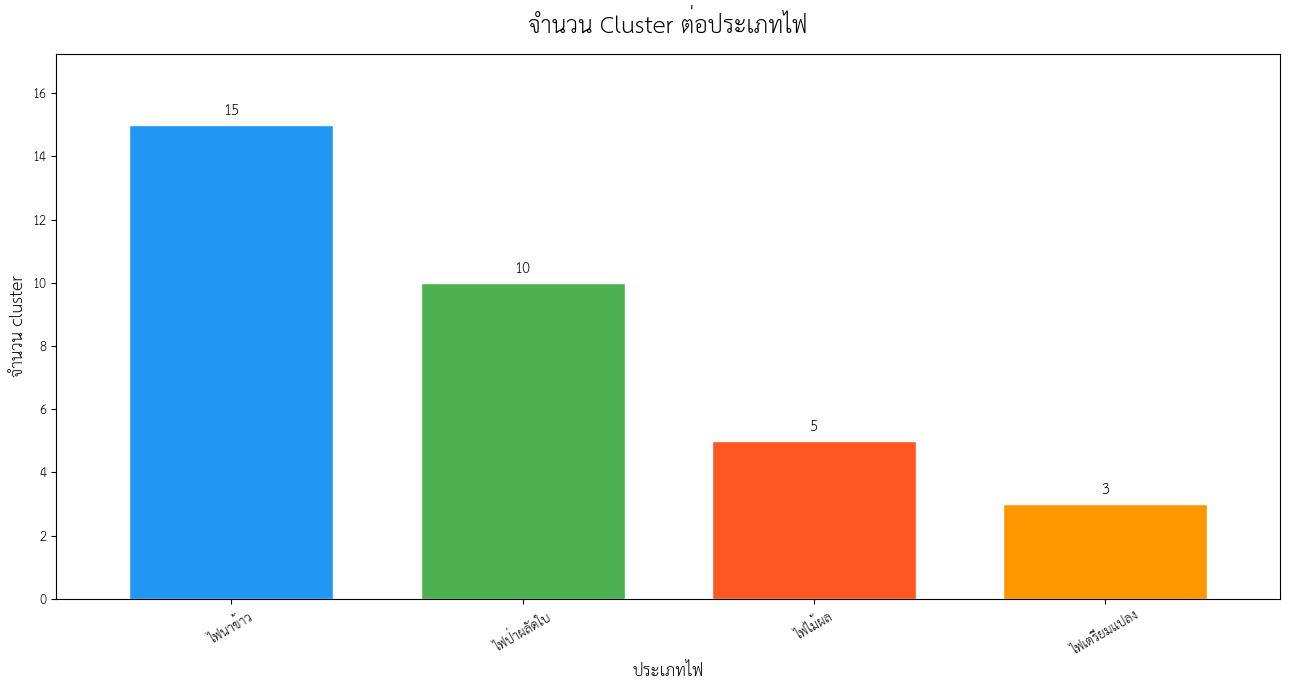

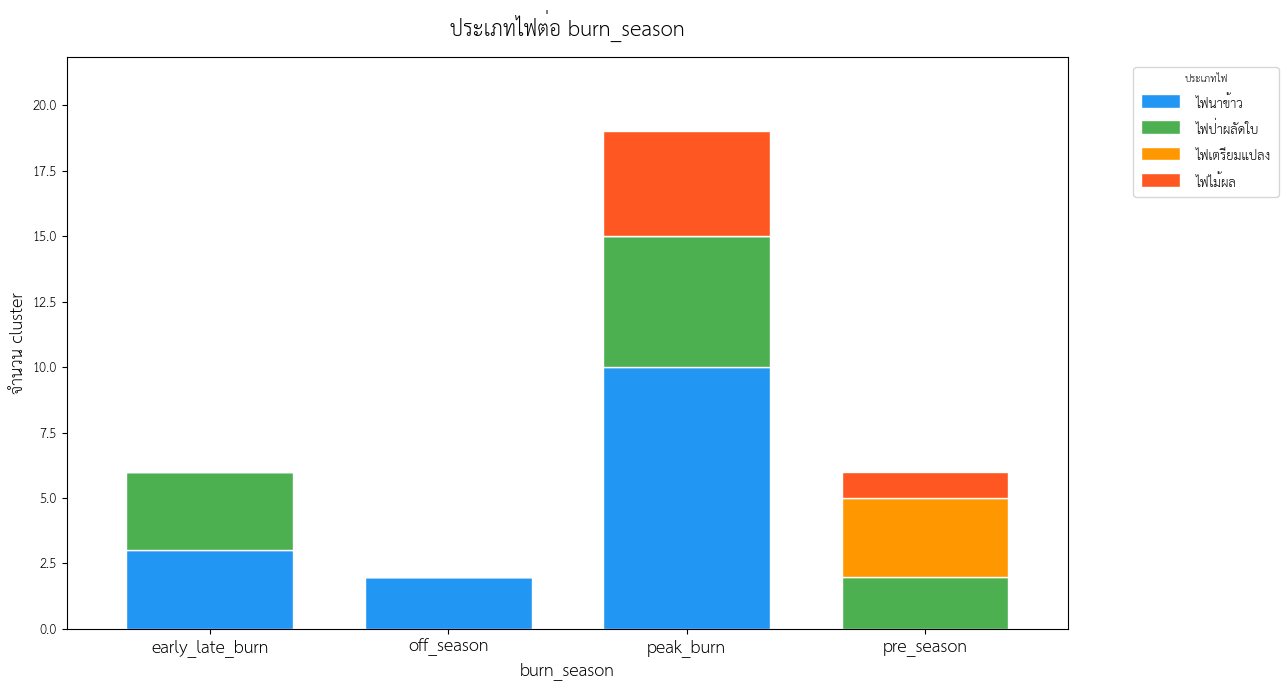

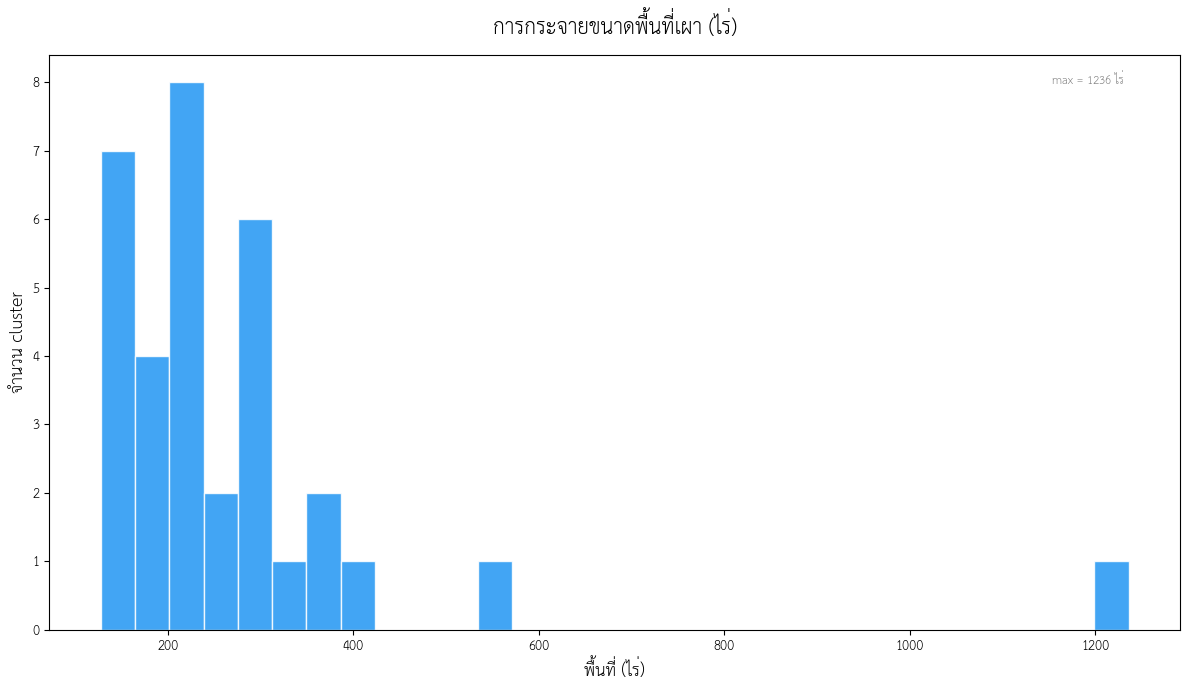

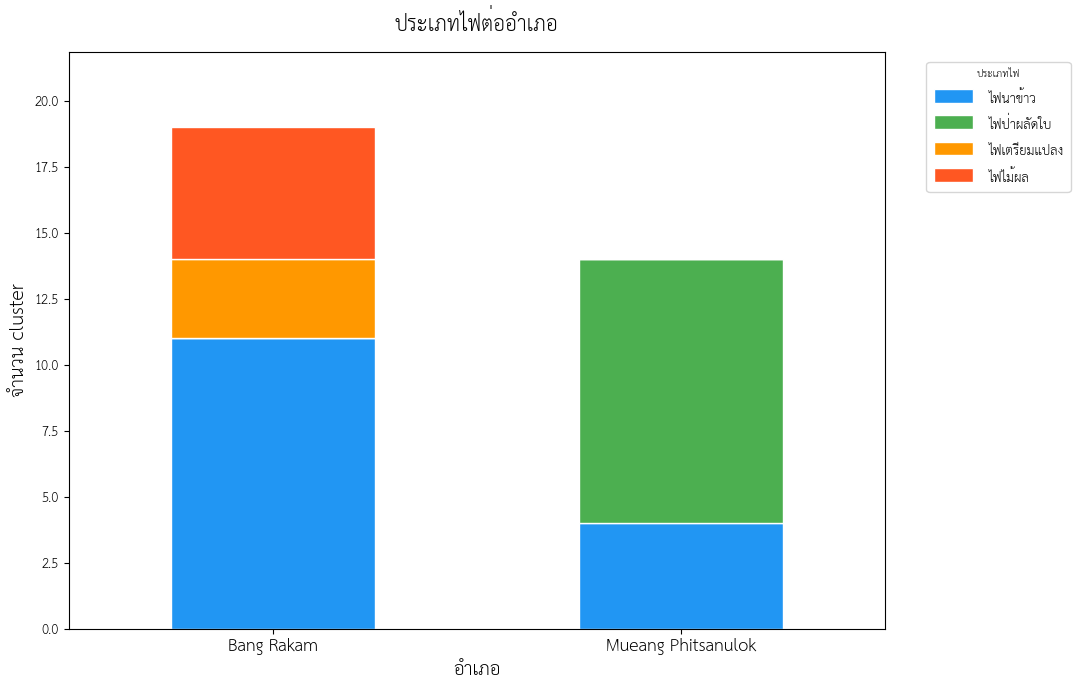

✓ บันทึกกราฟทั้ง 4 สำเร็จ


In [18]:
# กำหนดสีสำหรับแต่ละประเภทไฟ
fire_colors = {
    'ไฟนาข้าว'           : '#2196F3',
    'ไฟเตรียมแปลง'       : '#FF9800',
    'ไฟอ้อย'             : '#E91E63',
    'ไฟข้าวโพด'          : '#795548',
    'ไฟมันสำปะหลัง'      : '#9C27B0',
    'ไฟไม้ยืนต้น'        : '#009688',
    'ไฟไม้ผล'            : '#FF5722',
    'ไฟเกษตรผสมผสาน'     : '#FFC107',
    'ไฟพื้นที่เกษตรร้าง' : '#8D6E63',
    'ไฟพื้นที่เกษตรอื่น' : '#BCAAA4',
    'ไฟเกษตรไม่ระบุชนิด'       : '#90A4AE',
    'ไฟป่าผลัดใบ'        : '#4CAF50',
}

fb_counts = df_cluster['fire_behavior'].value_counts()
print("การกระจายของ fire_behavior:")
for fb, cnt in fb_counts.items():
    print(f"  {fb}: {cnt:,} cluster ({cnt/len(df_cluster)*100:.1f}%)")

# กราฟ 1: Fire behavior distribution
fig1, ax1 = plt.subplots(figsize=(13, 7))
colors1 = [fire_colors.get(fb, '#607D8B') for fb in fb_counts.index]
fb_counts.plot(kind='bar', ax=ax1, color=colors1, edgecolor='white', width=0.7)
ax1.set_title('จำนวน Cluster ต่อประเภทไฟ', fontsize=25, pad=15)
ax1.set_xlabel('ประเภทไฟ', fontsize=18)
ax1.set_ylabel('จำนวน cluster', fontsize=18)
ax1.tick_params(axis='x', rotation=30, labelsize=14)
ax1.tick_params(axis='y', labelsize=14)
ax1.set_ylim(0, fb_counts.max() * 1.15)  # เพิ่ม space ด้านบน
for i, v in enumerate(fb_counts.values):
    ax1.text(i, v + 0.3, str(v), ha='center', fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'phase3_plot1_fire_behavior_DBCV.png'), dpi=200)
plt.show()

# กราฟ 2: Fire behavior ต่อ burn_season
fig2, ax2 = plt.subplots(figsize=(13, 7))
cross = pd.crosstab(df_cluster['burn_season'], df_cluster['fire_behavior'])
colors2 = [fire_colors.get(c, '#607D8B') for c in cross.columns]
cross.plot(kind='bar', ax=ax2, stacked=True, color=colors2, edgecolor='white', width=0.7)
ax2.set_title('ประเภทไฟต่อ burn_season', fontsize=22, pad=15)
ax2.set_xlabel('burn_season', fontsize=18)
ax2.set_ylabel('จำนวน cluster', fontsize=18)
ax2.tick_params(axis='x', rotation=0, labelsize=18)
ax2.tick_params(axis='y', labelsize=14)
ax2.set_ylim(0, cross.sum(axis=1).max() * 1.15)
ax2.legend(loc='upper right', fontsize=14, title='ประเภทไฟ', title_fontsize=11,
           bbox_to_anchor=(1.22, 1))
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'phase3_plot2_burn_season_DBCV.png'), dpi=200, bbox_inches='tight')
plt.show()

# กราฟ 3: area_rai distribution
fig3, ax3 = plt.subplots(figsize=(12, 7))
ax3.hist(df_cluster['area_rai'], bins=30, color='#2196F3', edgecolor='white', alpha=0.85)
ax3.set_title('การกระจายขนาดพื้นที่เผา (ไร่)', fontsize=22, pad=15)
ax3.set_xlabel('พื้นที่ (ไร่)', fontsize=18)
ax3.set_ylabel('จำนวน cluster', fontsize=18)
ax3.tick_params(axis='x', labelsize=14)
ax3.tick_params(axis='y', labelsize=14)
ax3.text(0.95, 0.95, f"max = {df_cluster['area_rai'].max():.0f} ไร่",
         transform=ax3.transAxes, ha='right', fontsize=12, color='gray')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'phase3_plot3_area_DBCV.png'), dpi=200)
plt.show()

# กราฟ 4: cluster ต่ออำเภอ แยกตามประเภทไฟ
fig4, ax4 = plt.subplots(figsize=(11, 7))
cross2 = pd.crosstab(df_cluster['amphoe'], df_cluster['fire_behavior'])
colors4 = [fire_colors.get(c, '#607D8B') for c in cross2.columns]
cross2.plot(kind='bar', ax=ax4, stacked=True, color=colors4, edgecolor='white', width=0.5)
ax4.set_title('ประเภทไฟต่ออำเภอ', fontsize=22, pad=15)
ax4.set_xlabel('อำเภอ', fontsize=20)
ax4.set_ylabel('จำนวน cluster', fontsize=20)
ax4.tick_params(axis='x', rotation=0, labelsize=18)
ax4.tick_params(axis='y', labelsize=14)
ax4.set_ylim(0, cross2.sum(axis=1).max() * 1.15)
ax4.legend(loc='upper right', fontsize=14, title='ประเภทไฟ', title_fontsize=11,
           bbox_to_anchor=(1.24, 1))
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'phase3_plot4_amphoe_DBCV.png'), dpi=200, bbox_inches='tight')
plt.show()

print('✓ บันทึกกราฟทั้ง 4 สำเร็จ')

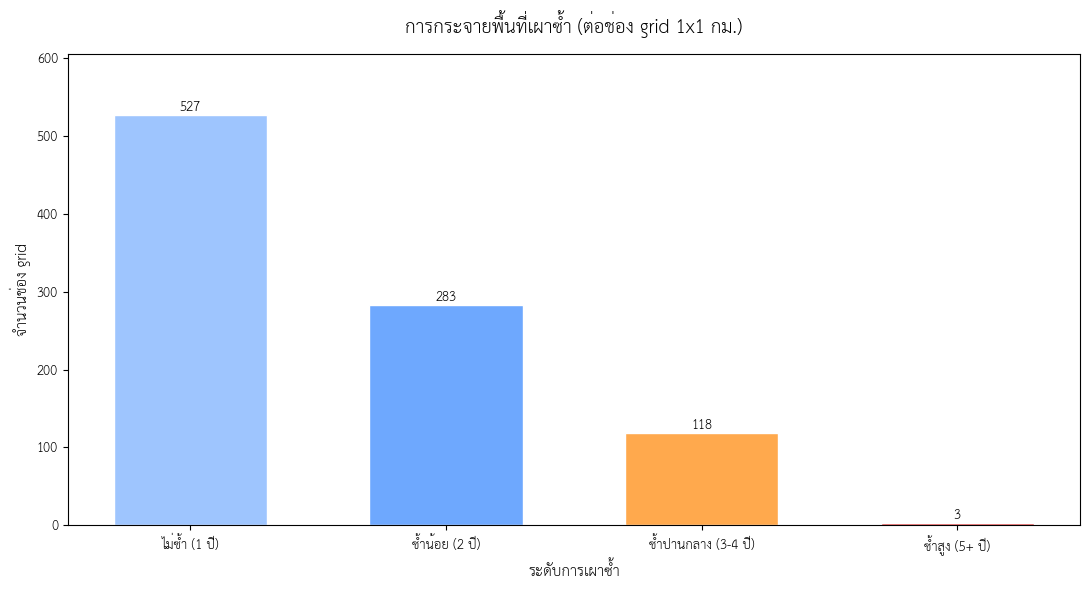

✓ บันทึกกราฟพื้นที่เผาซ้ำ (grid) สำเร็จ


In [19]:
# กราฟ 5: การกระจายพื้นที่เผาซ้ำ (จาก grid — ไม่ใช่ n_years_active ของ cluster)
fig5, ax5 = plt.subplots(figsize=(11, 6))
rl = gdf_recur['recur_level'].value_counts().sort_index()
labels5 = [x.split('_', 1)[1] for x in rl.index]
colors5 = ['#9EC5FE', '#6EA8FE', '#FFA94D', '#E03131'][:len(rl)]
ax5.bar(range(len(rl)), rl.values, color=colors5, edgecolor='white', width=0.6)
ax5.set_xticks(range(len(rl)))
ax5.set_xticklabels(labels5, fontsize=14)
ax5.set_title('การกระจายพื้นที่เผาซ้ำ (ต่อช่อง grid 1x1 กม.)', fontsize=20, pad=15)
ax5.set_xlabel('ระดับการเผาซ้ำ', fontsize=16)
ax5.set_ylabel('จำนวนช่อง grid', fontsize=16)
ax5.tick_params(axis='y', labelsize=14)
ax5.set_ylim(0, rl.max() * 1.15)
for x, v in enumerate(rl.values):
    ax5.text(x, v + rl.max()*0.01, str(v), ha='center', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'phase3_plot5_repeat_burn_DBCV.png'), dpi=200)
plt.show()
print('✓ บันทึกกราฟพื้นที่เผาซ้ำ (grid) สำเร็จ')

In [20]:
# ตาราง 1: สรุปต่อประเภทไฟ
print("=" * 60)
print("ตาราง 1: สรุปต่อประเภทไฟ")
print("=" * 60)

summary_fire = df_cluster.groupby('fire_behavior').agg(
    n_cluster    = ('cluster_id',    'count'),
    area_mean    = ('area_rai',      'mean'),
    area_sum     = ('area_rai',      'sum'),
    duration_mean= ('duration_days', 'mean'),
    frp_mean_avg = ('frp_mean',      'mean'),
    agri_mean    = ('agri_ratio',    'mean'),
).round(2)
summary_fire['pct'] = (summary_fire['n_cluster'] / summary_fire['n_cluster'].sum() * 100).round(1)
summary_fire.columns = ['จำนวน_cluster','พื้นที่เฉลี่ย_ไร่','พื้นที่รวม_ไร่',
                        'ระยะเวลาเฉลี่ย_วัน','FRP_เฉลี่ย_MW','สัดส่วนเกษตร','สัดส่วน_%']
print(summary_fire.to_string())

# ตาราง 2: สรุปต่ออำเภอ
print("\n" + "=" * 60)
print("ตาราง 2: สรุปต่ออำเภอ")
print("=" * 60)

summary_amphoe = df_cluster.groupby('amphoe').agg(
    n_cluster    = ('cluster_id',    'count'),
    area_sum     = ('area_rai',      'sum'),
    duration_mean= ('duration_days', 'mean'),
    frp_mean_avg = ('frp_mean',      'mean'),
    main_fire    = ('fire_behavior',  lambda x: x.mode()[0]),
).round(2)
summary_amphoe.columns = ['จำนวน_cluster','พื้นที่รวม_ไร่','ระยะเวลาเฉลี่ย_วัน',
                          'FRP_เฉลี่ย_MW','ประเภทไฟหลัก']
print(summary_amphoe.to_string())

# ตาราง 3: สรุปต่อปี
print("\n" + "=" * 60)
print("ตาราง 3: สรุปต่อปี")
print("=" * 60)

gdf_cluster['year_actual'] = pd.to_datetime(gdf_cluster['acq_date']).dt.year

summary_year = gdf_cluster.groupby('year_actual').agg(
    n_points     = ('cluster_id', 'count'),
    n_cluster    = ('cluster_id', 'nunique'),
    frp_mean_avg = ('frp',        'mean'),
).round(2)
summary_year.columns = ['จำนวนจุด', 'จำนวน_cluster', 'FRP_เฉลี่ย_MW']
print(summary_year.to_string())

# ตาราง 4: Cross table
print("\n" + "=" * 60)
print("ตาราง 4: จำนวน Cluster ต่อประเภทไฟ x อำเภอ")
print("=" * 60)
cross_table = pd.crosstab(
    df_cluster['amphoe'],
    df_cluster['fire_behavior'],
    margins=True,
    margins_name='รวม'
)
print(cross_table.to_string())

# ตาราง 5: สรุป repeat_burn
print("\n" + "=" * 60)
print("ตาราง 5: Cluster ที่ช่วงเวลาคาบเกี่ยว >=2 ปี (ไม่ใช่แผนที่เผาซ้ำ)")
print("=" * 60)

summary_repeat = df_cluster.groupby('repeat_burn').agg(
    n_cluster    = ('cluster_id',    'count'),
    area_mean    = ('area_rai',      'mean'),
    frp_mean_avg = ('frp_mean',      'mean'),
    n_years_mean = ('n_years_active','mean'),
).round(2)
summary_repeat.index = ['คาบเกี่ยว 1 ปี', 'คาบเกี่ยว >=2 ปี']
summary_repeat.columns = ['จำนวน_cluster','พื้นที่เฉลี่ย_ไร่','FRP_เฉลี่ย_MW','จำนวนปีเฉลี่ย']
print(summary_repeat.to_string())

# Export CSV
PATH_SUMMARY = os.path.join(BASE_PATH, "phase3_summary_tables_DBCV.csv")
with open(PATH_SUMMARY, 'w', encoding='utf-8-sig') as f:
    f.write("ตาราง 1: สรุปต่อประเภทไฟ\n")
    summary_fire.to_csv(f)
    f.write("\nตาราง 2: สรุปต่ออำเภอ\n")
    summary_amphoe.to_csv(f)
    f.write("\nตาราง 3: สรุปต่อปี\n")
    summary_year.to_csv(f)
    f.write("\nตาราง 4: Cross table\n")
    cross_table.to_csv(f)
    f.write("\nตาราง 5: Repeat Burn\n")
    summary_repeat.to_csv(f)

print(f"\n✓ Export ตารางสำเร็จ: {PATH_SUMMARY}")

ตาราง 1: สรุปต่อประเภทไฟ
               จำนวน_cluster  พื้นที่เฉลี่ย_ไร่  พื้นที่รวม_ไร่  ระยะเวลาเฉลี่ย_วัน  FRP_เฉลี่ย_MW  สัดส่วนเกษตร  สัดส่วน_%
fire_behavior                                                                                                              
ไฟนาข้าว                  15             251.32         3769.78                41.8           1.99           1.0       45.5
ไฟป่าผลัดใบ               10             330.73         3307.29                 8.3           2.00           0.0       30.3
ไฟเตรียมแปลง               3             184.79          554.38                28.0           0.75           1.0        9.1
ไฟไม้ผล                    5             272.99         1364.93                51.8           2.37           1.0       15.2

ตาราง 2: สรุปต่ออำเภอ
                    จำนวน_cluster  พื้นที่รวม_ไร่  ระยะเวลาเฉลี่ย_วัน  FRP_เฉลี่ย_MW ประเภทไฟหลัก
amphoe                                                                                           
Bang Rakam  

In [21]:
# CELL 7 — Merge กลับเข้า GeoDataFrame
gdf_out = gdf.merge(
    df_cluster[['cluster_id', 'n_points', 'area_rai', 'duration_days',
                'frp_mean', 'frp_max', 'agri_ratio', 'forest_ratio',
                'fire_behavior', 'fire_type', 'fire_type_detail',
                'n_years_active', 'years_active', 'repeat_burn',
                'dist_agri_m', 'dist_forest_m', 'year','burn_season_label','burn_season_display','doy_min', 'doy_max', 'day_pct']],
    on='cluster_id',
    how='left'
)
gdf_out.loc[gdf_out['cluster_id'] == -1, 'fire_behavior'] = 'noise'
print(f"จำนวนแถวหลัง merge: {len(gdf_out):,}")
print(f"Missing fire_behavior: {gdf_out['fire_behavior'].isna().sum()}")
print(f"columns: {len(gdf_out.columns)}")


จำนวนแถวหลัง merge: 2,458
Missing fire_behavior: 0
columns: 50


In [22]:
# --- CHECKPOINT 7 ---
print("\n[CHECKPOINT 7] ตรวจสอบ Merge")
assert len(gdf_out) == len(gdf), "✗ จำนวนแถวเปลี่ยนหลัง merge"
assert gdf_out['fire_behavior'].notna().all(), "✗ fire_behavior มี null"
print(f"✓ จำนวนแถวคงเดิม: {len(gdf_out):,}")
print("✓ fire_behavior ไม่มี null")


[CHECKPOINT 7] ตรวจสอบ Merge
✓ จำนวนแถวคงเดิม: 2,458
✓ fire_behavior ไม่มี null


In [23]:
# CELL 8 — ตรวจสอบความสมเหตุสมผล
print("agri_ratio ต่อประเภทไฟ (ควรสูงสำหรับไฟเกษตร):")
print(df_cluster.groupby('fire_behavior')['agri_ratio'].mean().round(3).sort_values(ascending=False).to_string())

print("\nburn_season ต่อประเภทไฟ:")
print(pd.crosstab(df_cluster['fire_behavior'],
                  df_cluster['burn_season'],
                  normalize='index').round(2).to_string())

df_cluster['density'] = df_cluster['n_points'] / df_cluster['area_rai']
print("\nCluster density ต่อประเภทไฟ:")
print(df_cluster.groupby('fire_behavior')['density'].mean().round(4).sort_values(ascending=False).to_string())

n_rep = int((gdf_recur['n_years'] >= 2).sum())
print(f"\nพื้นที่เผาซ้ำ (grid >=2 ปี): {n_rep:,}/{len(gdf_recur):,} ช่อง "
      f"({n_rep/len(gdf_recur)*100:.1f}%)")
print("\nการกระจายจำนวนปีที่เผาซ้ำ (ต่อช่อง grid):")
for y in range(1, int(gdf_recur['n_years'].max()) + 1):
    cnt = int((gdf_recur['n_years'] == y).sum())
    print(f"  เผา {y} ปี: {cnt} ช่อง")


agri_ratio ต่อประเภทไฟ (ควรสูงสำหรับไฟเกษตร):
fire_behavior
ไฟนาข้าว        1.0
ไฟเตรียมแปลง    1.0
ไฟไม้ผล         1.0
ไฟป่าผลัดใบ     0.0

burn_season ต่อประเภทไฟ:
burn_season    early_late_burn  off_season  peak_burn  pre_season
fire_behavior                                                    
ไฟนาข้าว                   0.2        0.13       0.67         0.0
ไฟป่าผลัดใบ                0.3        0.00       0.50         0.2
ไฟเตรียมแปลง               0.0        0.00       0.00         1.0
ไฟไม้ผล                    0.0        0.00       0.80         0.2

Cluster density ต่อประเภทไฟ:
fire_behavior
ไฟนาข้าว        0.0452
ไฟเตรียมแปลง    0.0326
ไฟไม้ผล         0.0313
ไฟป่าผลัดใบ     0.0160

พื้นที่เผาซ้ำ (grid >=2 ปี): 404/931 ช่อง (43.4%)

การกระจายจำนวนปีที่เผาซ้ำ (ต่อช่อง grid):
  เผา 1 ปี: 527 ช่อง
  เผา 2 ปี: 283 ช่อง
  เผา 3 ปี: 93 ช่อง
  เผา 4 ปี: 25 ช่อง
  เผา 5 ปี: 2 ช่อง
  เผา 6 ปี: 1 ช่อง


In [24]:
# --- CHECKPOINT 8 ---
print("\n[CHECKPOINT 8] ตรวจสอบ สรุปสถิติ")
n_fire_types = df_cluster['fire_behavior'].nunique()
all_years    = sorted(pd.to_datetime(gdf_cluster['acq_date']).dt.year.unique().tolist())

assert n_fire_types > 0,             "✗ ไม่มีประเภทไฟเลย"
assert summary_amphoe.shape[0] == 2, f"✗ อำเภอไม่ครบ 2 อำเภอ (พบ {summary_amphoe.shape[0]})"
assert len(all_years) >= 1,          "✗ ไม่มีข้อมูลปี"

print(f"✓ ประเภทไฟ: {n_fire_types} ประเภท")
print(f"✓ อำเภอครบ 2 อำเภอ: {list(summary_amphoe.index)}")
print(f"✓ ปีที่มีข้อมูล: {all_years}")



[CHECKPOINT 8] ตรวจสอบ สรุปสถิติ
✓ ประเภทไฟ: 4 ประเภท
✓ อำเภอครบ 2 อำเภอ: ['Bang Rakam', 'Mueang Phitsanulok']
✓ ปีที่มีข้อมูล: [2020, 2021, 2022, 2023, 2024, 2025]


In [25]:
# โหลดขอบเขตจังหวัดพิษณุโลก (สำหรับ clip polygon)
# PATH_BOUNDARY กำหนดไว้ใน path cell ด้านบน
boundary    = gpd.read_file(PATH_BOUNDARY)
phitsanulok = boundary[boundary["adm1_name"] == "Phitsanulok"].copy().to_crs("EPSG:4326")
print(f"✓ โหลดขอบเขตพิษณุโลก: {len(phitsanulok)} features")


✓ โหลดขอบเขตพิษณุโลก: 9 features


In [26]:
cluster_polygons = []

for cid, group in gdf_cluster.groupby('cluster_id'):
    coords      = list(zip(group['x_utm'], group['y_utm']))
    points_geom = [Point(x, y).buffer(375) for x, y in coords]
    union_geom  = unary_union(points_geom)

    row_stat = df_cluster[df_cluster['cluster_id'] == cid].iloc[0]

    cluster_polygons.append({
        'cluster_id'      : int(cid),
        'fire_behavior'   : row_stat['fire_behavior'],
        'fire_type'       : row_stat['fire_type'],
        'fire_type_detail': row_stat['fire_type_detail'],
        'repeat_burn'     : bool(row_stat['repeat_burn']),
        'n_points'        : int(row_stat['n_points']),
        'area_rai'        : float(row_stat['area_rai']),
        'duration_days'   : int(row_stat['duration_days']),
        'frp_mean'        : float(row_stat['frp_mean']),
        'frp_max'         : float(row_stat['frp_max']),
        'burn_season'     : row_stat['burn_season'],
        'amphoe'          : row_stat['amphoe'],
        'year'            : int(row_stat['year']),
        'n_years_active'  : int(row_stat['n_years_active']),
        'years_active'    : str(row_stat['years_active']),
        'dist_agri_m'     : float(row_stat['dist_agri_m']),
        'dist_forest_m'   : float(row_stat['dist_forest_m']),
        'burn_season_label': str(row_stat['burn_season_label']),
        'burn_season_display': str(row_stat['burn_season_display']),
        'geometry'        : union_geom,
        'doy_min'         : int(row_stat['doy_min']),
        'doy_max'         : int(row_stat['doy_max']),
        'day_pct'         : float(row_stat['day_pct']),
    })

gdf_poly = gpd.GeoDataFrame(cluster_polygons, crs='EPSG:32647')
gdf_poly = gdf_poly.to_crs('EPSG:4326')
gdf_poly = gpd.clip(gdf_poly, phitsanulok)

print(f"สร้าง polygon สำเร็จ: {len(gdf_poly):,} polygons")
print(f"CRS: {gdf_poly.crs}")
print(f"✓ Clip polygon สำเร็จ: {len(gdf_poly):,} polygons")
print(f"\nตัวอย่าง:")
print(gdf_poly[['cluster_id','fire_behavior','fire_type_detail','n_years_active','area_rai','amphoe']].head().to_string())


สร้าง polygon สำเร็จ: 33 polygons
CRS: EPSG:4326
✓ Clip polygon สำเร็จ: 33 polygons

ตัวอย่าง:
    cluster_id fire_behavior fire_type_detail  n_years_active  area_rai      amphoe
4            4      ไฟนาข้าว       agri_paddy               1    163.45  Bang Rakam
6            6      ไฟนาข้าว       agri_paddy               1    215.18  Bang Rakam
0            0      ไฟนาข้าว       agri_paddy               1    362.63  Bang Rakam
8            8  ไฟเตรียมแปลง       agri_paddy               2    144.52  Bang Rakam
17          17      ไฟนาข้าว       agri_paddy               1    304.94  Bang Rakam


In [27]:
# --- CHECKPOINT 8.5 ---
print("\n[CHECKPOINT 8.5] ตรวจสอบ Cluster Polygon")

diff = n_clusters - len(gdf_poly)
if diff > 0:
    print(f"⚠ Clip ตัด polygon ออก {diff} อัน (อยู่นอกพิษณุโลกทั้งหมด)")
else:
    print(f"✓ จำนวน polygon ครบ: {len(gdf_poly):,}")

assert len(gdf_poly) > 0,                     "✗ ไม่มี polygon เหลือเลย"
assert gdf_poly['geometry'].notna().all(),     "✗ มี polygon ที่เป็น null"
assert str(gdf_poly.crs) == 'EPSG:4326',      "✗ CRS ไม่ใช่ WGS84"
assert gdf_poly['fire_behavior'].notna().all(),"✗ fire_behavior มี null"

print(f"✓ จำนวน polygon หลัง clip: {len(gdf_poly):,}")
print(f"✓ CRS: {gdf_poly.crs}")
print(f"✓ ไม่มี null geometry")


[CHECKPOINT 8.5] ตรวจสอบ Cluster Polygon
✓ จำนวน polygon ครบ: 33
✓ จำนวน polygon หลัง clip: 33
✓ CRS: EPSG:4326
✓ ไม่มี null geometry


In [28]:
# ── Export ทุกไฟล์ (paths กำหนดไว้ใน path cell ด้านบน) ────────────────────
gdf_poly.to_file(PATH_POLY, driver='GPKG')
print(f"✓ Export cluster polygons: {PATH_POLY}")

# Export grid พื้นที่เผาซ้ำ (สำหรับทำแผนที่เผาซ้ำใน Phase 4)
gdf_recur.to_file(PATH_RECUR, driver='GPKG')
print(f"✓ Export repeat-burn grid: {PATH_RECUR}")
# Export GeoDataFrame หลัก
gdf_out.to_file(PATH_OUTPUT, driver='GPKG')
print(f"✓ Export hotspot classified: {PATH_OUTPUT}")
 
# Export cluster summary เป็น CSV
df_cluster.to_csv(PATH_CSV, index=False, encoding='utf-8-sig')
print(f"✓ Export cluster summary: {PATH_CSV}")

✓ Export cluster polygons: D:\gistnu\ST-DBSCAN\file_final\Phase 3 Final\cluster_polygons_final.gpkg
✓ Export repeat-burn grid: D:\gistnu\ST-DBSCAN\file_final\Phase 3 Final\repeat_burn_grid_final.gpkg
✓ Export hotspot classified: D:\gistnu\ST-DBSCAN\file_final\Phase 3 Final\hotspot_classified_final.gpkg
✓ Export cluster summary: D:\gistnu\ST-DBSCAN\file_final\Phase 3 Final\cluster_summary_final.csv


In [29]:
# --- CHECKPOINT FINAL ---
print("\n[CHECKPOINT FINAL] ตรวจสอบก่อนส่งต่อ Phase 4")
assert os.path.exists(PATH_OUTPUT), "✗ ไม่พบไฟล์ output"
assert os.path.exists(PATH_CSV),    "✗ ไม่พบไฟล์ CSV"
assert os.path.exists(PATH_POLY),   "✗ ไม่พบไฟล์ cluster polygon"
assert os.path.exists(PATH_RECUR),  "✗ ไม่พบไฟล์ repeat-burn grid"

gdf_verify = gpd.read_file(PATH_OUTPUT)
assert len(gdf_verify) == len(gdf_out),          "✗ จำนวนแถวไม่ตรง"
assert 'fire_behavior' in gdf_verify.columns,    "✗ ไม่มี fire_behavior"
assert 'cluster_id'    in gdf_verify.columns,    "✗ ไม่มี cluster_id"
assert 'n_years_active' in gdf_verify.columns,   "✗ ไม่มี n_years_active"
assert gdf_verify['fire_behavior'].notna().all(), "✗ fire_behavior มี null"

gdf_poly_verify = gpd.read_file(PATH_POLY)
assert len(gdf_poly_verify) > 0,                         "✗ ไม่มี polygon"
assert 'n_years_active' in gdf_poly_verify.columns,      "✗ polygon ไม่มี n_years_active"
assert gdf_poly_verify['fire_behavior'].notna().all(),    "✗ polygon fire_behavior มี null"

print(f"✓ จำนวนแถว: {len(gdf_verify):,}")
print(f"✓ CRS: {gdf_verify.crs}")
print(f"✓ cluster polygon: {len(gdf_poly_verify):,} polygons")
print(f"✓ columns: {len(gdf_verify.columns)} columns")

print(f"\n{'='*60}")
print(f"สรุปผล Phase 3:")
print(f"  จำนวน cluster ทั้งหมด : {n_clusters:,}")
for fb, cnt in fb_counts.items():
    print(f"  {fb}: {cnt:,} cluster")
_nr = int((gdf_recur["n_years"] >= 2).sum())
print("  พื้นที่เผาซ้ำ >=2 ปี (grid): " + str(_nr) + " ช่อง")
print(f"{'='*60}")
print("Phase 3 เสร็จสมบูรณ์ พร้อมเข้า Phase 4: Visualization")



[CHECKPOINT FINAL] ตรวจสอบก่อนส่งต่อ Phase 4
✓ จำนวนแถว: 2,458
✓ CRS: EPSG:32647
✓ cluster polygon: 33 polygons
✓ columns: 50 columns

สรุปผล Phase 3:
  จำนวน cluster ทั้งหมด : 33
  ไฟนาข้าว: 15 cluster
  ไฟป่าผลัดใบ: 10 cluster
  ไฟไม้ผล: 5 cluster
  ไฟเตรียมแปลง: 3 cluster
  พื้นที่เผาซ้ำ >=2 ปี (grid): 404 ช่อง
Phase 3 เสร็จสมบูรณ์ พร้อมเข้า Phase 4: Visualization
